# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [86]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [87]:
df.shape

(17379, 17)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [89]:
df = df.drop(['dteday'], axis=1) #dropping dteday since same information exists in other columns, and the data type is wrong

corr_matrix = df.corr()
corr_matrix['cnt'].sort_values(ascending=False)

,cnt
cnt,1.000000
registered,0.972151
casual,0.694564
temp,0.404772
atemp,0.400929
hr,0.394071
instant,0.278379
yr,0.250495
season,0.178056
mnth,0.120638


In [90]:
#dropping unnecessary variables
df = df.drop(['atemp','instant','casual', 'registered'], axis=1)

## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [91]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [92]:
from sklearn.preprocessing import StandardScaler

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {'n_estimators': [300, 500],'max_depth': [3, 5, 7],'learning_rate': [0.03, 0.05, 0.1],'subsample': [0.7, 0.8, 0.9, 1.0]}

grid_search = GridSearchCV(XGBRegressor(), param_grid, cv=5, verbose=2)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

print("Best Parameters:", best_params)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.7; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.7; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.7; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.7; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.7; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [94]:
#Linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [95]:
#XGBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_xgb = XGBRegressor(objective='reg:squarederror', n_estimators=best_params['n_estimators'],max_depth=best_params['max_depth'],learning_rate=best_params['learning_rate'],subsample=best_params['subsample'], random_state=42)

best_xgb.fit(X_train, y_train)

xgb_pred = best_xgb.predict(X_test)

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 104.97954256444909
Mean Squared Error: 19442.580886552176
R-squared: 0.3859994212622867


In [97]:
mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
r2 = r2_score(y_test, xgb_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 22.331982119151974
Mean Squared Error: 1397.3744529987305
R-squared: 0.9558706363182493


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

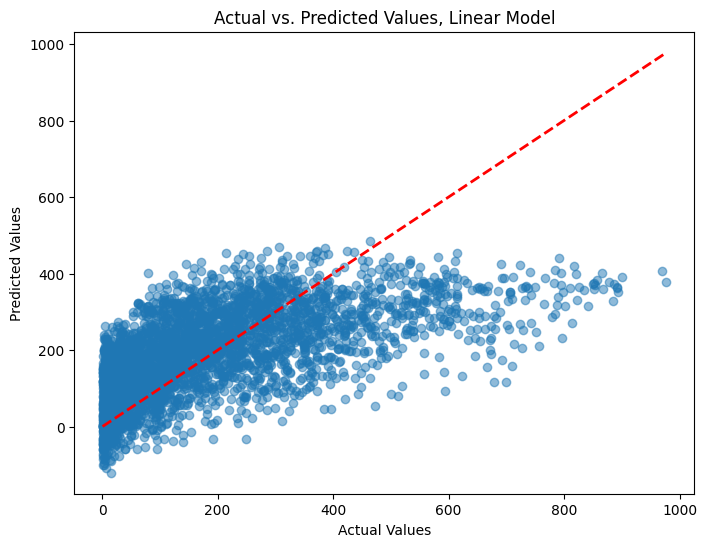

In [98]:
import matplotlib.pyplot as plt

#scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values, Linear Model")

#diagonal line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

plt.show()

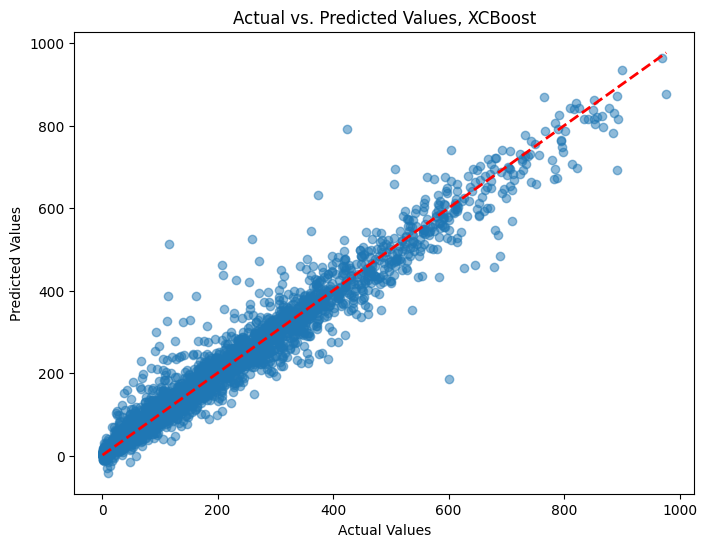

In [99]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_pred, alpha=0.5)  # Plot actual vs. predicted values

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values, XCBoost")

#diagonal line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

plt.show()